<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWI5emc0dnp2Z24ycDJibGkxbmM1ZjU2aDdqaW5yODdic3JzZjMxcyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/1gXg8Hrjah7bmm45W7/giphy.webp" alt="Eigen" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Examples of Solution Eigen values & Eigen Vectors</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### Libraries

In [1]:
import sys
import os
import glob
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
from numpy.linalg import eig, inv  
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_seismic_desing import *

## Example
![alt text](image-10.png)

#### Data

In [3]:
ProjecName = 'Edifico Rivadavia'

h = 3.6                                                                                                                         # Height of a single floor [m]
sto = 3                                                                                                                         # Number of floors
H = np.ones(sto) * h                                                                                                            # Vector containing the heights of all floors [m]
span = [1,1]                                                                                                                    # Number of spans in x and y directions
LV = 7                                                                                                                          # longitud de vanos (se emplea unicamente para graficar)
Afloor = (span[0] * LV) * (span[1] * LV)
WD = 0.30
WL = 0.20
Wpp = 1.20
wpi = Afloor * (1.0* WD + 1.0 * WL + 1.0 * Wpp) 
E = 2000000                                                                                                                     # Elastic modulus in [T/m^2]
u = 0.2                                                                                                                         # Poisson's ratio of the material (dimensionless).
G = E / (2*(1 + u))                                                                                                             # Shear modulus calculated using the relationship between E and u [T/m^2].
f = 1/5                                                                                                                         # shape factor
C = 0.30                                                                                                                        # Size of the column in [m] (Square Columns)
iner = C**4 / 12                                                                                                                # Moment of inertia of columns [m^4]
A = C * C                                                                                                                       # Area [m^2]
INERs = np.ones(sto) * iner                                                                                                     # Vector containing the inertia of columns per floor [m^4]
g = 9.8                                                                                                                         # Gravitational acceleration [m/s^2]
MPall = np.ones(sto) * (wpi / g)                                                                                                # Vector containing the mass of each floor [T·s^2/m]
maxdrift = 1.50                                                                                                                 # Define maximum allowed drift percentage
fss = 1.5                                                                                                                        # factor de escala para dibujo de columnas y vigas
C = C * fss                                                                                                                      # tamaño de columnas y vigas para dibujo


#----------City---------
city = 'Pichinca - Quito - Cumbaya'
#---------Soild type--------
suelo = 'C'
#--------- PGA TR475 --------
z = 0.47
#--------- Amplification Soild Factors -------
zone = 'IV'
fads = [1.19,1.08,1.17]
rr = 1.0
R = 7
I = 1.25

#------- Colocation r -------
r = np.ones(len(H))


# Display results for verification
print('\x1b[1;34m')
print("="*120)
print('\x1b[1;34m  Floor Weigth:', wpi)
print('\x1b[1;34m  Vector of floor heights (H):', H)
print('\x1b[1;34m  Vector of column inertias (INERs):', INERs)
print('\x1b[1;34m  Vector of floor masses (MPall):', MPall)
print('\x1b[1;34m  Vector of r:', r)
print("="*120)


  Floor Weigth: 83.3
  Vector of floor heights (H): [3.6 3.6 3.6]
  Vector of column inertias (INERs): [0.000675 0.000675 0.000675]
  Vector of floor masses (MPall): [8.5 8.5 8.5]
  Vector of r: [1. 1. 1.]


#### Stiffness Matrix for each Floor

In [4]:
Kfloor = Assamble_K_M(span=span,iner= iner,H=H,E=E,G=G,f=f,A=A, Mall= MPall)
k = Kfloor.kfloor()
k_frame = pd.DataFrame(k, columns=['Stiffness Vector'])                                                                        # Create a DataFrame from the stiffness vector
k_frame.head(len(k))

number of columns per floor =  4


,Stiffness Vector
0,1384.27464
1,1384.27464
2,1384.27464


#### Structure Stiffness Matrix

In [5]:
K = Kfloor.matrixK(k)
K_frame = pd.DataFrame(K, columns=[f'Column {i+1}' for i in range(K.shape[1])])                                                 # Convert K (2D array) into a DataFrame with column names based on the number of columns                    
K_frame.head(len(k))

,Column 1,Column 2,Column 3
0,2768.54928,-1384.27464,0.00000
1,-1384.27464,2768.54928,-1384.27464
2,0.00000,-1384.27464,1384.27464


#### Structure Mass Matrix

In [6]:
M = Kfloor.matrixM()
M_frame = pd.DataFrame(M, columns=[f'Mass {i+1}' for i in range(M.shape[1])])                                                    # Convert the diagonal matrix to a DataFrame with appropriate column names
M_frame.head(len(M))

,Mass 1,Mass 2,Mass 3
0,8.5,0.0,0.0
1,0.0,8.5,0.0
2,0.0,0.0,8.5


#### Solution Eigen Values and Eigen Vectors

In [7]:
Eigen = Eig_Normalize(K = K, M = M)
w2, v, a = Eigen.eigen()
idx = np.argsort(w2)                                                                                                             # Sort eigenvalues in ascending order
w2 = w2[idx]                                                                                                                     # Reorganize eigenvalues
w = np.sqrt(w2)                                                                                                                  # Compute the natural angular frequencies w = sqrt(w2)
T = 2 * np.pi / w                                                                                                                # Compute the periods T = 2 * pi / w
f = 1 / T                                                                                                                        # Compute the natural frequencies f = 1 / T
v = v[:, idx]                                                                                                                    # Reorganize eigenvectors according to sorted eigenvalues
v_normalized = Eigen.normalize_modes(v)                                                                                             # Normalize the mode shapes using the mass matrix

# Combine the results into a DataFrame
Resul_frame = pd.DataFrame({
    'Angular Frequencies': w,                                                                                                    # Column for angular frequencies w
    'Periods [s]': T,                                                                                                            # Column for periods T
    'Frequencies [Hz]': f                                                                                                        # Column for frequencies f
})

# Add normalized mode shapes to the DataFrame
for i in range(v_normalized.shape[1]):                                                                                           # Loop through each normalized mode shape
    Resul_frame[f'Normalized Mode {i+1}'] = v_normalized[:, i]                                                                   # Add each normalized mode shape as a separate column

Resul_frame.head(len(T))

,Angular Frequencies,Periods [s],Frequencies [Hz],Normalized Mode 1,Normalized Mode 2,Normalized Mode 3
0,5.679401,1.106311,0.903905,0.112498,-0.252781,-0.202714
1,15.913328,0.394838,2.532685,0.202714,-0.112498,0.252781
2,22.995425,0.273236,3.659836,0.252781,0.202714,-0.112498


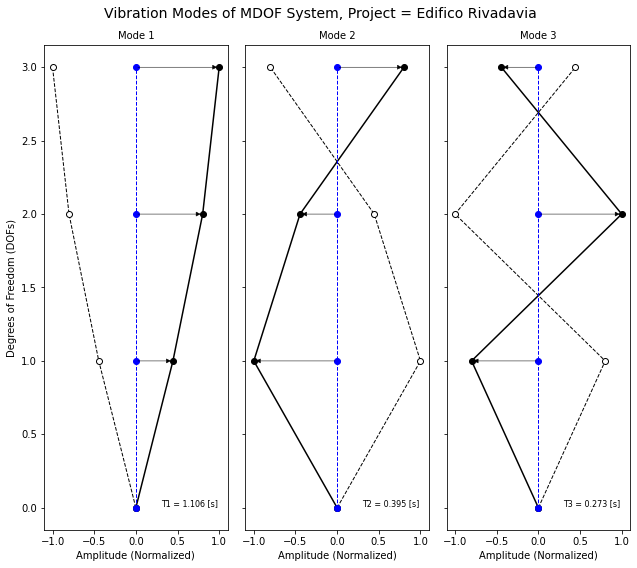

In [8]:
plotvibration = Plot_vibration(v = v_normalized,num_modes_to_plot= len(T), T = T, plotmax= 5, project= ProjecName)
plotvibration.plot_vibration_modes_subplots()

#### Calculate the modal excitation factor for each structural period (**$\{L\}$**).

$$ \{L\} = [\mathbf{\Phi}_n]^\mathrm{T} [M] \{r\} $$


In [9]:
L = np.dot(np.dot(v_normalized.T, M), r)                                                                                          # Calculation of the modal excitation factor vector {L} using the formula {L} = [Φ_n]^T [M] {r}.
L_frame = pd.DataFrame(L, columns= ['Modal excitation factor'])                                                                   # Convert the modal excitation factor vector {L} into a DataFrame for better visualization.
L_frame.head(len(L)) 

,Modal excitation factor
0,4.827942
1,-1.381797
2,-0.530669


#### Effective Modal Mass.

$$ 
   \{M_{e,i}\} = \frac{\{L_i\}^2}{\sum M_{\text{total}}} 
   $$

In [10]:
Mtotal = np.sum(np.diag(M))                                                                                                       # Calculate the total mass by summing the diagonal elements of the mass matrix M
M_e = []                                                                                                                          # Initialize a list to store the effective modal masses

for i in np.arange(0, len(T), 1):                                                                                                 # Iterate through each mode
    M_e.append(L[i]**2 / Mtotal * 100)                                                                                            # Calculate the effective modal mass for each mode and append to the list in "%"

M_e_frame = pd.DataFrame(M_e, columns= ['Effective Modal Mass [%]'])                                                              # Create a DataFrame from the effective modal mass array
M_e_frame.head(len(M_e))                                                                                                          # Display the DataFrame with effective modal masses

,Effective Modal Mass [%]
0,91.407949
1,7.487698
2,1.104353


#### Cumulative Effective Mass.

$$ 
   \{M_{e,\text{cumulative}}\} = \sum_{i=1}^{N} \{M_{e,i}\} 
   $$

In [11]:
M_e_acum = np.zeros(len(M_e))                                                                                                     # Initialize an array of zeros to store the cumulative effective modal masses
M_e_acum[0] = M_e[0]                                                                                                              # Set the first element of the cumulative array to the first effective modal mass

for i in np.arange(1, len(M_e), 1):                                                                                               # Loop through the remaining effective modal masses
    M_e_acum[i] = M_e_acum[i - 1] + M_e[i]                                                                                        # Add the current effective modal mass to the cumulative total

M_e_acum_frame = pd.DataFrame(M_e_acum, columns= ['Cumulative Effective Mass [%]'])                                               # Create a DataFrame from the cumulative effective modal mass array
M_e_acum_frame.head(len(M_e_acum))                                                                                                # Display the DataFrame with cumulative effective modal masses

,Cumulative Effective Mass [%]
0,91.407949
1,98.895647
2,100.000000


#### Spectral Analisys

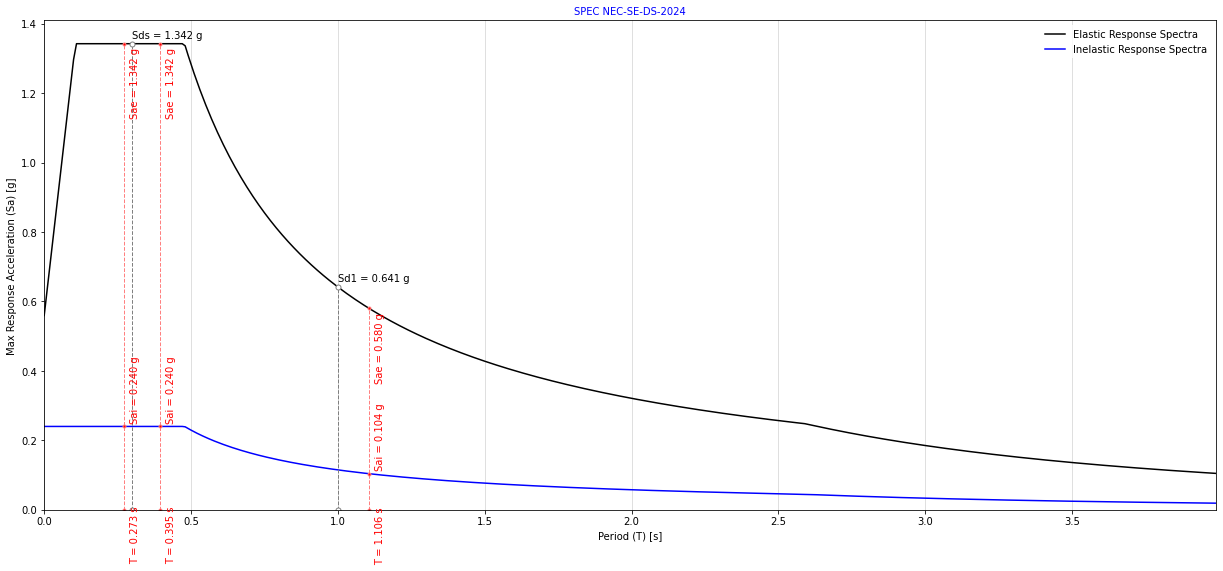

,Period [s],Sae [g],Sai [g]
0,1.106311,0.579768,0.10353
1,0.394838,1.342320,0.23970
2,0.273236,1.342320,0.23970


In [12]:
Spec = SpecNec2024_Sae_Sai_modal(Tfind = T, fads = fads, I = I, z = z, n = 2.4, R = R, r = rr, Tf = 4, dT = 0.01)
Resul, SaeF, SaiF, Tl, Sds, Sd1 = Spec.plot_SpecNEC_modal()
Resul

#### Calculate the maximum modal displacement ($ q_n^{\mathrm{max}} $) and the maximum modal lateral force ($ Q_n^{\mathrm{max}} $) for each mode.

   $$ \{q_n^{\mathrm{max}}\} = \frac{L_n \cdot S_{ai,n} \cdot g }{\omega_n^2} \cdot \{\mathbf{\Phi}_n\} $$

   $$ \{Q_n^{\mathrm{max}}\} = L_n \cdot S_{ai,n} \cdot g \cdot [M] \cdot \{\mathbf{\Phi}_n\} $$

In [13]:
qn = []                                                                                                                          # Initialize a list to store the maximum modal displacements
Qn = []                                                                                                                          # Initialize a list to store the maximum modal lateral force
g = 9.8                                                                                                                          # Gravitational acceleration in m/s^2

Cd = R * 0.75                                                                                                                    # Inelastic displacement amplification factor based on the response modification coefficient (R)

for i in np.arange(0, len(M_e_acum), 1):                                                                                         # Loop through the modes to calculate the maximum modal displacement
    qn.append(((L[i] * SaiF[i] * g )/ (w2[i])) * v_normalized[:, i] * Cd)                                                        # Calculate and append the maximum modal displacement for each mode
    Qn.append(L[i] * SaiF[i] * g * np.dot(M, v_normalized[:, i]))                                                                # Calculate and append the maximum modal lateral force for each mode

qn_array = np.array(qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation
Qn_array = np.array(Qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation


qn_columns = [f'qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN
Qn_columns = [f'Qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN

rows = pd.Index(f'd{i + 1}' for i in range(len(T)))

qn_frame = pd.DataFrame(qn_array, columns=qn_columns, index = rows)                                                              # Create a DataFrame with appropriate column names
qn_frame.head(len(qn))                                                                                                           # Display the DataFrame with all modal displacements

,qn1,qn2,qn3
d1,0.089692,0.017011,0.002509
d2,0.161619,0.007570,-0.003129
d3,0.201536,-0.013641,0.001392


In [14]:
Qn_frame = pd.DataFrame(Qn_array, columns=Qn_columns, index = rows)                                         # Create a DataFrame with appropriate column names
Qn_frame.head(len(Qn))  

,Qn1,Qn2,Qn3
d1,4.684010,6.974311,2.147938
d2,8.440295,3.103860,-2.678435
d3,10.524875,-5.592963,1.192016


#### Determination of the Number of Vibration Modes Required to Achieve at Least 90% Mass Participation

In [15]:
threshold_modal_shape = np.where(M_e_acum >= 90)[0][0] + 1                                                                       # Find the first modal shape where the cumulative effective mass reaches at least 90% of the total mass

print('\x1b[1;34m')
print('='*120)               
print('\x1b[1;34mThe modal shape where at least 90% of the mass participation is reached:', threshold_modal_shape)               # Print the modal shape where the condition is met
print(f'\x1b[1;34mThe cumulative effective mass at this modal shape is: {M_e_acum[threshold_modal_shape - 1]:.3f} %')            # Print the cumulative mass at the identified modal shape
print('='*120)  


The modal shape where at least 90% of the mass participation is reached: 1
The cumulative effective mass at this modal shape is: 91.408 %



#### Superimpose the necessary modal responses (displacements and forces) to achieve at least 90% mass participation using combination rules


* Square Root of Summary of Squares (SRSS)
$$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

$$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( Q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

In [16]:
qtotal_SRSS = qn_array[:, 0] ** 2                                                                                                # Initialize qtotal with the square of the first column (modal displacements)
Qtotal_SRSS = Qn_array[:, 0] ** 2                                                                                                # Initialize Qtotal with the square of the first column (modal forces)

for i in np.arange(1, threshold_modal_shape, 1):                                                                                 # Iterate through modes up to the threshold for 90% mass participation
    qtotal_SRSS = qtotal_SRSS + qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal displacement
    Qtotal_SRSS = Qtotal_SRSS + Qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal force

qtotal_SRSS = qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal displacements
Qtotal_SRSS = Qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal forces

# Create a DataFrame to store the SRSS results
Resul_SRSS = pd.DataFrame({'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
                           'SRSS of maximum modal lateral force [T]': Qtotal_SRSS}, index= rows)   
Resul_SRSS.head(len(L))                                                                                                          # Display the DataFrame with SRSS results

,SRSS of maximum modal inelastic displacement [m],SRSS of maximum modal lateral force [T]
d1,0.089692,4.684010
d2,0.161619,8.440295
d3,0.201536,10.524875


* Complete Quadratic Combination (CQC)</u>.  

   $$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} q_n^{\mathrm{max}} q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

   $$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} Q_n^{\mathrm{max}} Q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

In [17]:
qtotal_cqc = 0                                                                                                                   # Initialize total displacement for CQC
Qtotal_cqc = 0                                                                                                                   # Initialize total lateral force for CQC

rho = np.identity(len(L))                                                                                                        # Define the modal correlation coefficient matrix (identity as placeholder)

for n in np.arange(0, len(L), 1):                                                                                                # Loop through each mode (row index)
    for m in np.arange(0, len(L), 1):                                                                                            # Loop through each mode (column index)
        qtotal_cqc += qn_array[:, n] * qn_array[:, m] * rho[n, m]                                                                # Add contributions of displacement modes using correlation coefficients
        Qtotal_cqc += Qn_array[:, n] * Qn_array[:, m] * rho[n, m]                                                                # Add contributions of force modes using correlation coefficients

qtotal_cqc = qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total displacement
Qtotal_cqc = Qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total lateral force

qtotal = qtotal_cqc                                                                                                              # se graba esa variable para usos porsteriores

# Create a DataFrame to store the CQC results
Resul_cqc = pd.DataFrame({"CQC of maximum modal inelastic displacement [m]": qtotal_cqc,
                          "CQC of maximum modal lateral force [T]": Qtotal_cqc}, index = rows)

Resul_cqc.head(len(L))                                                                                                           # Display the DataFrame with CQC results

,CQC of maximum modal inelastic displacement [m],CQC of maximum modal lateral force [T]
d1,0.091325,8.671482
d2,0.161827,9.383312
d3,0.202002,11.978111


#### Base Shear
$$ V_{\mathrm{total}, i} = \sum_{j=i}^{N} Q_{\mathrm{total}, j} $$

In [18]:
VD_srss = np.sum(Qtotal_SRSS)                                                                                                    # Summation of all floor forces (SRSS)
VD_cqc = np.sum(Qtotal_cqc)                                                                                                      # Summation of all floor forces (CQC)

Result_Basal = pd.DataFrame({
    "SRSS Base Shear [T]": [VD_srss],                                                                                            # Convert scalar to list
    "CQC Base Shear [T]": [VD_cqc]                                                                                               # Convert scalar to list
})

Result_Basal.head()                                                                                                              # Display DataFrame

,SRSS Base Shear [T],CQC Base Shear [T]
0,23.64918,30.032905


#### Minimum Code-Prescribed Shear

Although this exercise does not aim to perform a modal spectral analysis based on regulatory constraints, to better align this example with real-world procedures, the following expressions outline the minimum shear force requirements as prescribed in **[ASCE 7-16](https://www.asce.org/publications-and-news/asce-7)**.


The total seismic base shear force $V$ is determined using the following equation:

$$ V = C_s W $$

where:

- $C_s$ = Seismic response coefficient, defined as:

$$ C_s = \frac{S_{DS}}{\frac{R}{I_e}} $$

- $S_{DS}$ = Design spectral response acceleration for short periods.

- $R$ = Response modification factor, obtained from Table **12.2-1 ASCE**.

- $I_e$ = Importance factor, determined from Section **11.5.1 ASCE**.

- $W$ = Effective seismic weight of the structure, as defined in Section **12.7.2 ASCE**.


Additionally, the seismic response coefficient $C_s$ must satisfy the following limits:

- **For structures where the period $T \leq T_L$:**

$$ C_s = \frac{S_{D1}}{T \left( \frac{R}{I_e} \right)} $$

- **For structures where $T > T_L$:**

$$ C_s = \frac{S_{D1} T_L}{T^2 \left( \frac{R}{I_e} \right)}  $$

- **Lower bound condition for $C_s$:**

$$ C_s = 0.044 S_{DS} I_e \geq 0.01 $$

In [19]:
Csmin = np.maximum(0.044 * Sds * I, 0.01)                                                                                        # Compute the minimum seismic coefficient (Csmin) as per ASCE 7-16 Equation 12.8-5

if T[0] <= Tl:                                                                                                               # Check if the first fundamental period (T1) is less than or equal to the characteristic period (Tl)
    Cs = np.maximum(Sd1 / (T[0] * (R / I)), Csmin)                                                                 # Compute Cs using ASCE 7-16 Equation 12.8-3 and ensure it is not less than Csmin
else:
    if T[0] > Tl:                                                                                                            # If the first fundamental period (T1) is greater than the characteristic period (Tl)
        Cs = np.maximum((Sd1 * Tl) / (T[0]**2 * (R / I)), Csmin )                                                              # Compute Cs using ASCE 7-16 Equation 12.8-4 and ensure it is not less than 0.01

total_weight = Mtotal * g                                                                                                        # Compute the total seismic weight of the building in tons (W = Mtotal * g)
VD_ASCE = total_weight * Cs                                                                                                      # Compute the ASCE 7-16 minimum base shear force (V = Cs * W)

VD_ASCE_frame = pd.DataFrame({'Minimum Base Shear ASCE [T]': [VD_ASCE]})                                                         # Create a DataFrame to store the minimum base shear force value
VD_ASCE_frame.head()                                                                                                             # Display the first row of the DataFrame

,Minimum Base Shear ASCE [T]
0,25.872127


In [20]:
V = np.maximum(VD_cqc, VD_srss)                                                                                                 # Compute the base shear (V) as the maximum value between CQC and SRSS base shear forces

fscale = VD_ASCE / V                                                                                                            # Compute the scaling factor to adjust results to ASCE 7-16 minimum base shear

q_ASCE = qtotal_cqc * fscale                                                                                                        # Scale the maximum modal inelastic displacement to match ASCE base shear
Q_ASCE = Qtotal_cqc * fscale                                                                                                    # Scale the modal lateral force at each floor according to ASCE

Result_ASCE_df = pd.DataFrame({'ASCE of maximum modal lateral force [T]': Q_ASCE,                                                  # Create a DataFrame with ASCE-adjusted maximum modal lateral forces
                             'ASCE of maximum modal inelastic displacement [m]': q_ASCE})                                            

print(f'V_ASCE = {np.sum(Q_ASCE)} [T]')
Result_ASCE_df.head(len(Q_ASCE))                                                                                                   # Display the full DataFrame with ASCE-adjusted results


V_ASCE = 25.872126716127127 [T]


,ASCE of maximum modal lateral force [T],ASCE of maximum modal inelastic displacement [m]
0,7.470129,0.078673
1,8.083342,0.139407
2,10.318656,0.174016


In [21]:
H_cumulative = np.cumsum(H)                                                                                                      # Compute the cumulative height by summing the story heights sequentially
H_cumulative = np.insert(H_cumulative, 0, 0)
Qtotal_SRSS = np.insert(Qtotal_SRSS, 0, 0)                                                                                       # Prepend a zero to the beginning of the Qtotal_SRSS array
Qtotal_cqc = np.insert(Qtotal_cqc, 0, 0)                                                                                         # Prepend a zero to the beginning of the Qtotal_cqc array
Q_ASCE = np.insert(Q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the Q_ASCE array

print(H_cumulative)

# q_ASCE = np.insert(q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the q_ASCE array
M_overturning_ASCE = np.cumsum(Q_ASCE * H_cumulative)[::-1]                                                                      # Overturning moment ASCE [T·m] (Inverted)
print(M_overturning_ASCE)
# Vtotal_ASCE = np.append(VD_ASCE, 0)                                                                                          # Append a zero to the end of the Vtotal_ASCE array

# M_overturning_CQC = np.cumsum(Qtotal_cqc * H_cumulative)[::-1]                                                                   # Overturning moment CQC [T·m] (Inverted)
# M_overturning_SRSS = np.cumsum(Qtotal_SRSS * H_cumulative)[::-1]                                                                 # Overturning moment SRSS [T·m] (Inverted)
# Vtotal_srss = np.append(VD_srss, 0)                                                                                          # Append a zero to the end of the Vtotal_srss array
# Vtotal_cqc = np.append(VD_cqc, 0)                                                                                            # Append a zero to the end of the Vtotal_cqc array
# ds_SRSS = np.insert(qtotal_SRSS, 0, 0)                                                                                               # Prepend a zero to the beginning of the ds_SRSS array
# ds_CQC = np.insert(qtotal_cqc, 0, 0)                                                                                                 # Prepend a zero to the beginning of the ds_CQC array

# Summary= pd.DataFrame({"Height": H_cumulative,                                                                                   # Create a DataFrame with all the Results
#                            "CQC of maximum modal lateral force [T]": Qtotal_cqc,
#                            'SRSS of maximum modal lateral force [T]': Qtotal_SRSS,
#                            'ASCE of maximum modal lateral force [T]': Q_ASCE,
#                            "CQC Floor Shear Force [T]": Vtotal_cqc,                                                               
#                            "SRSS Floor Shear Force [T]": Vtotal_srss,
#                            "ASCE Floor Shear Force [T]": Vtotal_ASCE,
#                            "CQC Overturning Moment [T·m]": M_overturning_CQC, 
#                            "SRSS Overturning Moment [T·m]": M_overturning_SRSS,
#                            "ASCE Overturning Moment [T·m]": M_overturning_ASCE,
#                            'CQC of maximum modal inelastic displacement [m]': qtotal_cqc,
#                            'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
#                            'ASCE of maximum modal inelastic displacement [m]': q_ASCE,
#                            "SRSS inelastic drift [ % ]": ds_SRSS,
#                            "CQC inelastic drift [ % ]": ds_CQC})

# Summary.head(len(ds_CQC))

[ 0.   3.6  7.2 10.8]
[196.5340073   85.09252565  26.89246561   0.        ]
